
# Attention 

! Using `attention_utils.py`

This notebook demonstrates **soft**, **self**, **cross**, **local**, and **hard** attention and shared visualization helpers.


## Examples for a sentence & embeddings
We'll use a Romanian sentence for all demos so differences are easy to compare.


In [5]:

src_text = "Pacienții cu diabet necesită screening regulat"
source_tokens = simple_tokenize(src_text)
emb = TinyEmbed(sorted(set(source_tokens + ["<query>"])), d=16)
X = emb(source_tokens).unsqueeze(0)  # [1, n, d]
print('Tokens:', source_tokens)


Tokens: ['Pacienții', 'cu', 'diabet', 'necesită', 'screening', 'regulat']


## setup

In [4]:
import torch, numpy as np
import matplotlib.pyplot as plt
from attention_utils import (
    simple_tokenize, TinyEmbed,
    scaled_dot_product_attention,
    soft_attention_unified, self_attention_unified, cross_attention_unified,
    causal_mask, local_mask, sliding_window_mask, longformer_mask, block_sparse_mask,
    dilated_mask, strided_mask, bigbird_mask, mask_density,
    AttentionVisualizer, multihead_self_attention_demo,
    greedy_hard_attention, gumbel_softmax_attention,
    run_demo
)

# Reproducibility
torch.manual_seed(42); np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 3)
plt.rcParams['figure.dpi'] = 140


# Attention mechanisms


## 1) Soft attention (q=1) — bars
A single query attends over the source (encoder) tokens.

Soft attention = cross-attention (query from one context --> attends to another context).

Differentiable mechanism using softmax and is widely used in NLP and transformers.

> soft attention = asking a librarian for one book

Primary Use Case: 
- Encoder–Decoder models (e.g., Neural Machine Translation, Image Captioning).


Why:
- A decoder needs to selectively focus on relevant parts of the source sequence while generating each output token.


Applications:
- Machine Translation: Decoder attends to source sentence for each target word.
- Speech Recognition: Decoder attends to acoustic features.
- Image Captioning: Text decoder attends to image regions.
- Summarization: Decoder attends to document sentences.


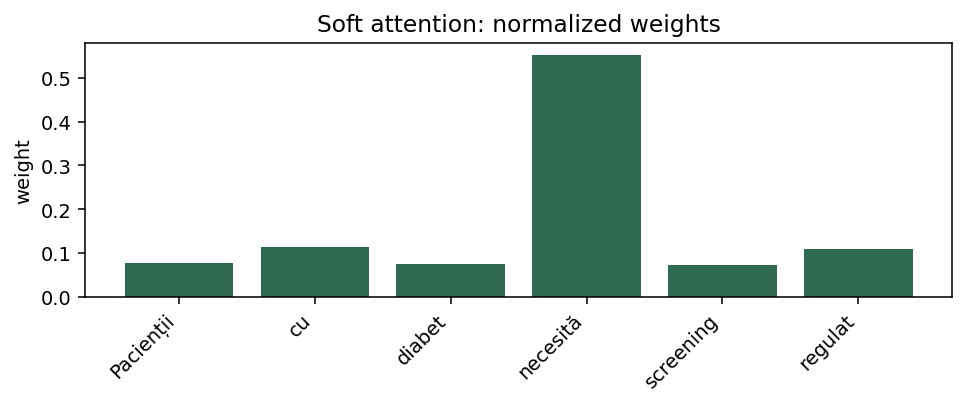

In [7]:

q = emb(["<query>"]).unsqueeze(0)  # [1, 1, d]
ctx_soft, W_soft = soft_attention_unified(q, X, X)
viz = AttentionVisualizer(source_tokens)
viz.show_bars(W_soft[0,0].detach().numpy(), title="Soft attention: normalized weights")



## 2) Self attention (q=n) — matrix
Every token attends to every other token. 
We call the attention function with the same tensor for queries, keys, and values. 

Self-attention = intra-attention (tokens attend to each other within the same context). 

> self-attention = group discussion where everyone listens to everyone


Primary Use Case:
- Contextual representation learning within a single sequence.

Why:
- Captures long-range dependencies without recurrence.

Applications:
- Transformers (BERT, GPT): NLP tasks like QA, summarization, sentiment analysis.
- Vision Transformers (ViT): Image classification, object detection.
- Multimodal Models: CLIP (text + image), Audio-Visual tasks.
- Graph Attention Networks: Nodes attend to neighbors.


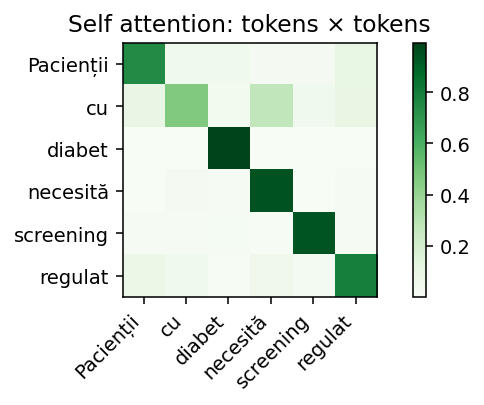

In [ ]:

ctx_self, W_self = self_attention_unified(X)
viz = AttentionVisualizer(source_tokens)
viz.show_matrix(W_self[0].detach().numpy(), title="Self attention: tokens × tokens")



## 3) Cross attention — matrix (q × n)
Queries from one sequence attend to keys/values from another sequence (e.g., decoder → encoder).

Cross-attention = interaction between two contexts

> cross-attention = asking a bilingual friend to interpret a sentence for you


Primary Use Case
- Encoder–Decoder architectures in Transformers and related models.

Why
- Enables the decoder to incorporate information from the source sequence while generating each target token.
Critical for tasks where input and output are in different modalities or languages.

Applications
- Machine Translation: Decoder attends to encoder’s representation of the source sentence.
- Speech-to-Text: Text decoder attends to acoustic features from the audio encoder.
- Image Captioning: Text decoder attends to visual embeddings from an image encoder.
- Multimodal Models: Text attends to image/video features (e.g., CLIP, Vision-Language Transformers).
- Document Summarization: Decoder attends to full document representation for generating summaries.


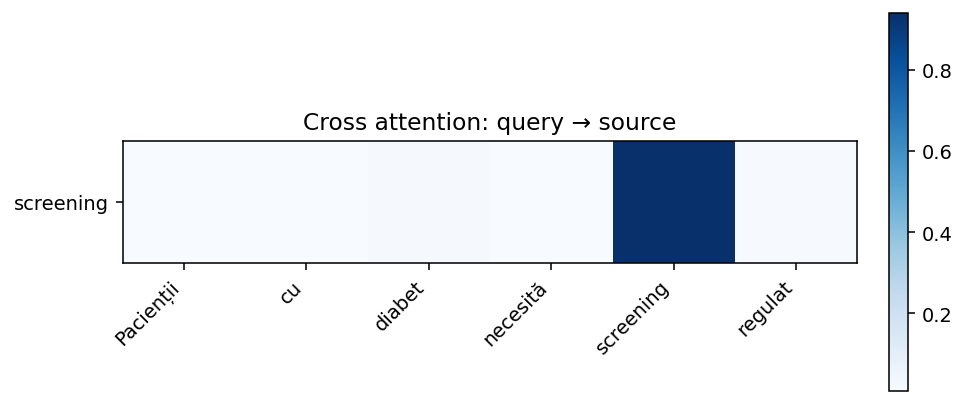

In [ ]:

queries = emb(["screening"]).unsqueeze(0)  # pretend decoder query
ctx_cross, W_cross = cross_attention_unified(queries, X, X)
viz = AttentionVisualizer(["screening"], source_tokens)
viz.show_matrix(W_cross[0].detach().numpy(), title="Cross attention: query → source", cmap="Blues")


# Computational perspectives

Sparse attention = local attention
-  instead of computing attention weights for all $n \times n$ token pairs (dense), it restricts computation to a subset of positions (e.g., a sliding window). This reduces complexity from $O(n^2)$ to approximately $O(n \cdot k)$, where $k$ is the average number of positions each token attends to.

Remember:
- Dense attention: Every token attends to every other token → full $n \times n$ matrix.
- Sparse attention: Only a fraction of entries are computed (others are masked out).

Sparse attention patterns can be categorized by how they select positions:

- Fixed Patterns
    - Sliding Window (Local)
        - Effect
            - Each token attends to neighbors within ± w positions.
        - Impact on output:
            - Captures local context well (e.g., phrases, short dependencies).
            - Cannot directly model long-range relationships—information propagates slowly across layers.
        - Use-cases: 
            - local attention in speech models.
            - Long sequences where local coherence matters (speech, text chunks)
        - Example:
            - Longformer
    - Block-Sparse
        - Effect: 
            - Sequence divided into blocks; tokens attend within block and to neighboring blocks.
        - Impact on output:
            - Preserves local structure within blocks.
            - Adds limited cross-block context for hierarchical patterns.
        - Use case: 
            - Long documents, structured data.
        - Example: 
            - BigBird, Reformer (with hashing).

- Random Patterns
    - Randomly selected positions per token to improve connectivity.
    - Example: BigBird adds random links to avoid isolated regions.

- Dilated / Strided Patterns
    - Effect: 
        - Tokens attend at regular intervals (e.g., every d steps).
    - Impact on output:
        - Expands receptive field without full cost.
        - Good for periodic or hierarchical patterns (e.g., images, audio).
    - Use case:
        - Vision Transformers, audio modeling.
    - Example: 
        - Sparse Transformers for images.

- Causal masks
    - Effect: 
        - Lower-triangular mask ensures each token only attends to previous tokens.
    - Impact on output:
        - Enables autoregressive generation.
        - No future context --> strictly left-to-right dependency.
    - Use case: 
        - GPT-style models, text generation.
    - Example:
        - GPT, Transformer-XL.

- Learnable Patterns
    - Attention sparsity learned during training (dynamic).
    - Example: Routing Transformers, Adaptive Sparse Attention.

- Global Tokens
    - A few tokens (e.g., [CLS]) attend to all positions and vice versa.
    - Impact on output:
        - Local tokens still focus on nearby context.
        - Global tokens aggregate document-level information, enabling classification or summarization.
    - Use case: 
        - Document QA, summarization, classification.
    - Example: Longformer, BigBird.



## 4) Local (windowed) self-attention — banded matrix
Restricts attention to a local neighborhood around each token (± w positions). Instead of attending to all tokens (as in full self-attention), each token only considers nearby tokens, creating a band-diagonal attention matrix. 

> Local attention = focused conversation with your immediate neighbors (only talking to people next to you)


Primary Use Case
- Long sequences where full self-attention is too expensive (e.g., documents, audio streams, DNA sequences).

Why
- Reduces computational complexity from $O(n^2)$ to approximately $O(n \cdot w)$.
Preserves local context, which is often most relevant in structured data (text, speech, vision).

Applications
- Longformer and BigBird: Efficient Transformers for long documents.
- Speech Recognition: Focus on local acoustic frames.
- Vision Models: Local patches in images (similar to convolutional receptive fields).
- Genomics: Attention over local nucleotide windows.

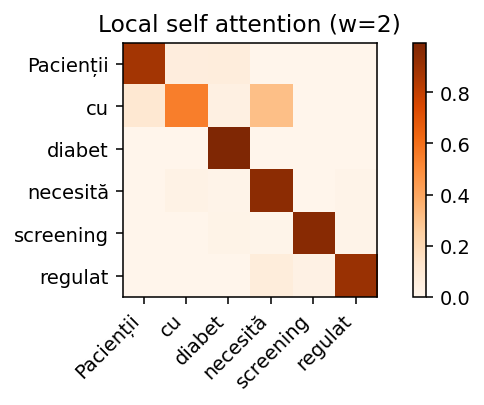

Density: 0.6666666666666666


In [ ]:

w = 2
M_local = local_mask(q=X.size(1), n=X.size(1), w=w, device=X.device)
ctx_local, W_local = self_attention_unified(X, mask=M_local)
viz = AttentionVisualizer(source_tokens)
viz.show_matrix(W_local[0].detach().numpy(), title=f"Local self attention (w={w})", cmap="Oranges")
print('Density:', mask_density(M_local)[0])


BigBird and Longformer are Transformer variants designed to handle long sequences efficiently by introducing sparse attention patterns.

**Longformer**
Core Idea: 
- Uses a sliding window attention pattern combined with global tokens.

Attention Pattern:
- Each token attends to its local neighborhood (± w positions).
- A few global tokens (e.g., [CLS]) attend to all tokens and vice versa.

Complexity:
- Reduces from $O(n^2)$ to approximately $O(n \cdot w)$.

Strengths:
- Great for tasks where local context dominates (e.g., long documents).
- Global tokens allow summary-like tokens to aggregate global info.

Applications:
- Document classification, QA over long texts, summarization.


**BigBird**

Core Idea:
- Combines local window, random attention, and global tokens.

Attention Pattern:
- Local window: similar to Longformer.
- Random links: each token attends to a few random positions → improves connectivity.
- Global tokens: same as Longformer.

Complexity:
- Also O(n) on average, but with better graph connectivity for theoretical guarantees.

Strengths:
- Proven to approximate full attention under certain conditions.
- Handles long-range dependencies better than pure local attention.

Applications:
- Long text QA, summarization, language modeling for very long sequences.

Longformer: window w=2, globals=[0]  → density=0.833  avg kept/row≈5.0
BigBird   : window w=2, globals=[0], random r=3 → density=0.944  avg kept/row≈5.7


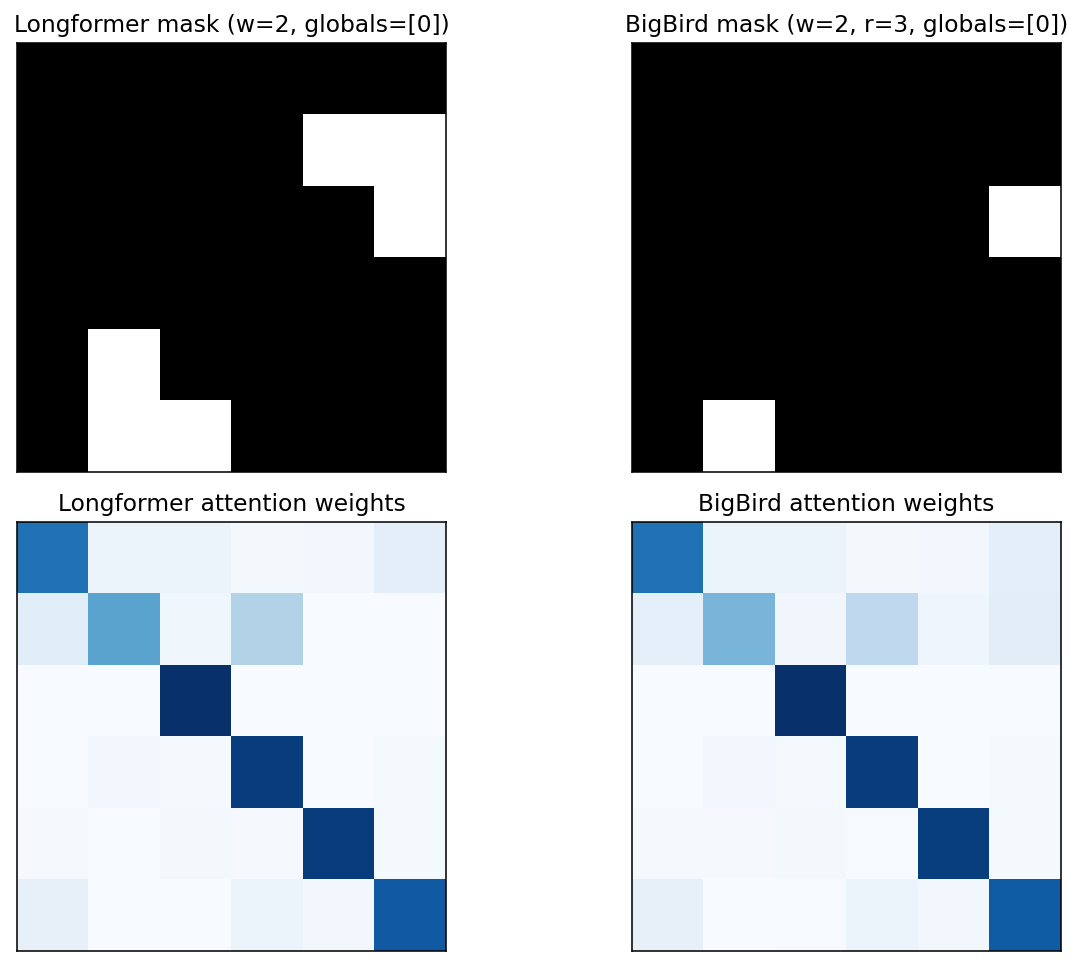

In [ ]:

# %% [longformer vs bigbird side-by-side]
import torch
import numpy as np
import matplotlib.pyplot as plt
from attention_utils import (
    longformer_mask, bigbird_mask, mask_density,
    self_attention_unified, AttentionVisualizer
)

# Use the same token sequence you already have in the notebook
# e.g., source_tokens and X = emb(source_tokens).unsqueeze(0)
n = X.size(1)
device = X.device

# --- Build masks ---
w = 2                    # local window size
globals = [0]            # make the first token global (e.g., [CLS])
r = 3                    # random links per row for BigBird

M_long = longformer_mask(n, w=w, global_idx=globals, device=device)   # [1, n, n]
M_bb   = bigbird_mask(n, w=w, r=r, global_idx=globals, device=device) # [1, n, n]

# --- Report densities (fraction of kept edges) ---
dens_long = mask_density(M_long)[0]
dens_bb   = mask_density(M_bb)[0]
print(f"Longformer: window w={w}, globals={globals}  → density={dens_long:.3f}  avg kept/row≈{dens_long*n:.1f}")
print(f"BigBird   : window w={w}, globals={globals}, random r={r} → density={dens_bb:.3f}  avg kept/row≈{dens_bb*n:.1f}")

# --- Compute attention with each mask (for visualization completeness) ---
_, W_long = self_attention_unified(X, mask=M_long)  # [1, n, n]
_, W_bb   = self_attention_unified(X, mask=M_bb)    # [1, n, n]

# --- Side-by-side visualization of masks (binary) and weights (soft) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# Masks (binary)
axes[0,0].imshow(M_long[0].cpu().numpy().astype(float), cmap="Greys")
axes[0,0].set_title(f"Longformer mask (w={w}, globals={globals})")
axes[0,0].set_xticks([]); axes[0,0].set_yticks([])

axes[0,1].imshow(M_bb[0].cpu().numpy().astype(float), cmap="Greys")
axes[0,1].set_title(f"BigBird mask (w={w}, r={r}, globals={globals})")
axes[0,1].set_xticks([]); axes[0,1].set_yticks([])

# Weights (softmax attention with those masks)
axes[1,0].imshow(W_long[0].detach().cpu().numpy(), cmap="Blues")
axes[1,0].set_title("Longformer attention weights")
axes[1,0].set_xticks([]); axes[1,0].set_yticks([])

axes[1,1].imshow(W_bb[0].detach().cpu().numpy(), cmap="Blues")
axes[1,1].set_title("BigBird attention weights")
axes[1,1].set_xticks([]); axes[1,1].set_yticks([])

plt.tight_layout(); plt.show()

# (Optional) labeled visualization with tokens for one or both panels:
# AttentionVisualizer(source_tokens).show_matrix(W_long[0].detach().cpu().numpy(), "Longformer weights", cmap="Blues")
# AttentionVisualizer(source_tokens).show_matrix(W_bb[0].detach().cpu().numpy(),   "BigBird weights",   cmap="Blues")


Summary vs Dense baseline (higher cosine ⇒ more similar to dense outputs):
  Dense (no mask)                  | seq_cos=1.000  W_cos=1.000  dense
  Sliding (w=2)                    | seq_cos=0.999  W_cos=0.994  density=0.667 (kept=24/36)
  Longformer (w=2, G=[0])          | seq_cos=0.999  W_cos=0.997  density=0.833 (kept=30/36)
  Block (bs=3, band=1)             | seq_cos=1.000  W_cos=1.000  density=1.000 (kept=36/36)
  Dilated (w=2, d=3)               | seq_cos=0.988  W_cos=0.969  density=0.333 (kept=12/36)
  Strided (s=4)                    | seq_cos=0.984  W_cos=0.975  density=0.278 (kept=10/36)
  BigBird (w=2, r=3, G=[0])        | seq_cos=1.000  W_cos=1.000  density=0.944 (kept=34/36)
  Causal (autoregressive)          | seq_cos=0.974  W_cos=0.972  density=0.583 (kept=21/36)
  Local (q=n, w=2)                 | seq_cos=0.999  W_cos=0.994  density=0.667 (kept=24/36)


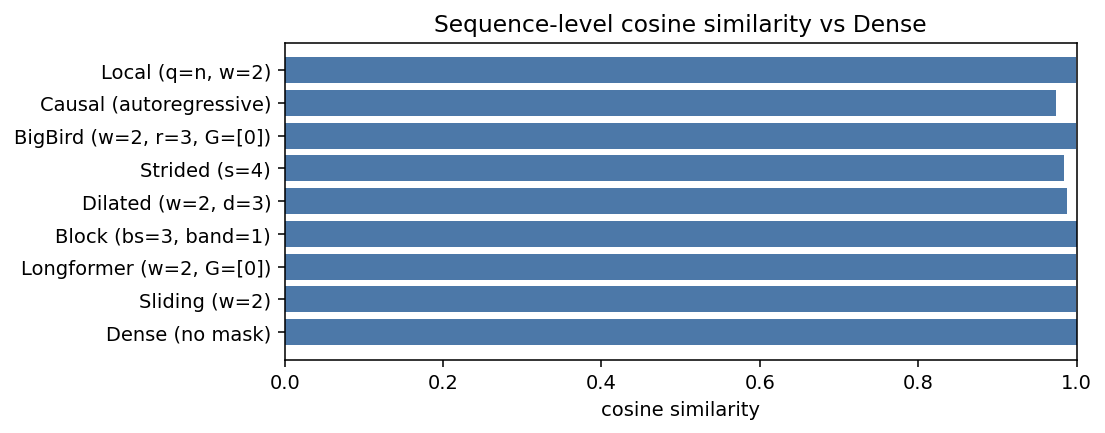

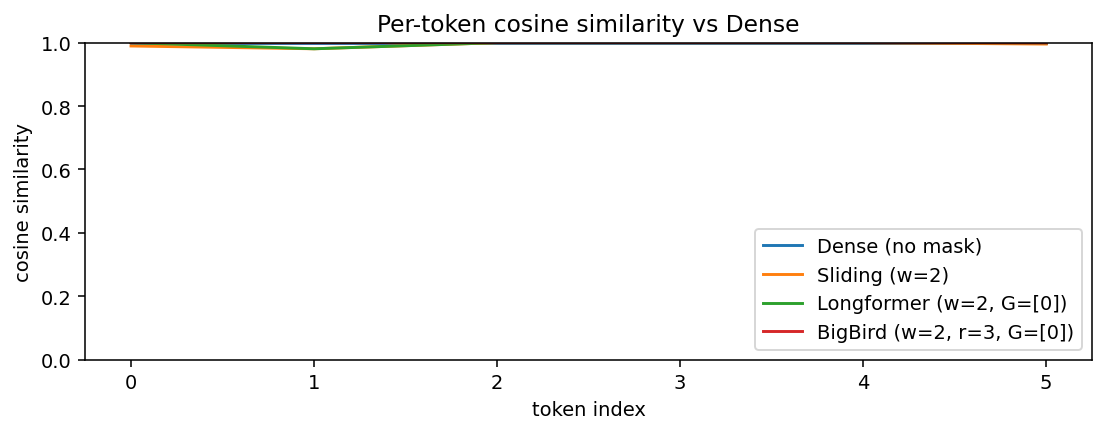

In [ ]:

# %% [compare outputs across masks vs dense baseline]
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from attention_utils import (
    sliding_window_mask, longformer_mask, block_sparse_mask,
    dilated_mask, strided_mask, bigbird_mask, causal_mask, local_mask,
    mask_density, self_attention_unified, AttentionVisualizer
)

# ---- Inputs (from your notebook context) ----
n = X.size(1)
device = X.device
tokens = source_tokens

# ---- Build masks ----
w = 2
globals_idx = [0]   # treat first token as global (e.g., [CLS])
block_size, band   = 3, 1
dilation, stride   = 3, 4
r_random           = 3

masks = {
    "Dense (no mask)"           : None,
    f"Sliding (w={w})"          : sliding_window_mask(n, w, device=device),
    f"Longformer (w={w}, G={globals_idx})": longformer_mask(n, w, global_idx=globals_idx, device=device),
    f"Block (bs={block_size}, band={band})" : block_sparse_mask(n, block_size=block_size, band=band, device=device),
    f"Dilated (w={w}, d={dilation})" : dilated_mask(n, w, dilation=dilation, device=device),
    f"Strided (s={stride})"      : strided_mask(n, stride=stride, include_self=True, device=device),
    f"BigBird (w={w}, r={r_random}, G={globals_idx})" : bigbird_mask(n, w=w, r=r_random, global_idx=globals_idx, device=device),
    "Causal (autoregressive)"    : causal_mask(n, device=device),
    f"Local (q=n, w={w})"        : local_mask(q=n, n=n, w=w, device=device),
}

# ---- Baseline: dense self-attention ----
ctx_dense, W_dense = self_attention_unified(X, mask=None)  # [1, n, d], [1, n, n]
dense_vec  = ctx_dense[0]        # [n, d]
dense_mean = dense_vec.mean(dim=0, keepdim=True)  # [1, d]
W_dense_vec = W_dense.reshape(1, -1)  # [1, n*n]

# ---- Compare function ----
def compare_to_dense(mask, name):
    # Run self-attention with the given mask
    ctx, W = self_attention_unified(X, mask=mask)
    vec = ctx[0]                            # [n, d]
    mean_vec = vec.mean(dim=0, keepdim=True)     # [1, d]
    W_vec = W.reshape(1, -1)                # [1, n*n]

    # Per-token cosine similarity with dense outputs
    per_token_cos = F.cosine_similarity(vec, dense_vec, dim=-1)  # [n]

    # Sequence-level cosine similarity (mean-pooled)
    seq_cos = F.cosine_similarity(mean_vec, dense_mean, dim=-1).item()  # scalar

    # Weight-matrix cosine similarity (flattened)
    W_cos = F.cosine_similarity(W_vec, W_dense_vec, dim=-1).item()  # scalar

    # Mask density (if mask exists)
    density = None
    if mask is not None:
        dens, nz, total = mask_density(mask)
        density = (dens, nz, total)
    return {
        "name": name,
        "per_token_cos": per_token_cos.detach().cpu(),
        "seq_cos": seq_cos,
        "W_cos": W_cos,
        "density": density,
        "W": W[0].detach().cpu().numpy(),   # for optional visualization
    }

# ---- Compute comparisons for all masks ----
results = []
for name, M in masks.items():
    results.append(compare_to_dense(M, name))

# ---- Print a concise summary ----
print("Summary vs Dense baseline (higher cosine ⇒ more similar to dense outputs):")
for r in results:
    dens_str = "dense" if r["density"] is None else f"density={r['density'][0]:.3f} (kept={r['density'][1]}/{r['density'][2]})"
    print(f"  {r['name']:<32} | seq_cos={r['seq_cos']:.3f}  W_cos={r['W_cos']:.3f}  {dens_str}")

# ---- Plot sequence-level similarities ----
plt.figure(figsize=(8, 3.2))
labels = [r["name"] for r in results]
seq_vals = [r["seq_cos"] for r in results]
plt.barh(labels, seq_vals, color="#4C78A8")
plt.title("Sequence-level cosine similarity vs Dense")
plt.xlabel("cosine similarity")
plt.xlim(0, 1.0)
plt.tight_layout(); plt.show()

# ---- Plot per-token cosine curves for a few representative masks ----
# Choose 4 representative masks to avoid clutter
chosen = ["Dense (no mask)",
          f"Sliding (w={w})",
          f"Longformer (w={w}, G={globals_idx})",
          f"BigBird (w={w}, r={r_random}, G={globals_idx})"]

plt.figure(figsize=(8, 3.2))
for r in results:
    if r["name"] in chosen:
        plt.plot(range(n), r["per_token_cos"].numpy(), label=r["name"])
plt.title("Per-token cosine similarity vs Dense")
plt.xlabel("token index")
plt.ylabel("cosine similarity")
plt.ylim(0, 1.0)
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()
 
# seq_cos (bar chart): The closer to 1.0, the more the overall sequence representation (mean-pooled output) resembles dense attention.

# per_token_cos (line plot): Shows which tokens diverge most from dense attention under each mask.
# - Divergence at boundaries suggests masks restrict context too much there.
# - Peaks near global tokens indicate stronger agreement with dense attention.

# W_cos: Similarity between attention weight matrices.
# - Useful for understanding how masks alter where attention is placed even if outputs (after value projection) remain relatively similar.

In [9]:
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
import torch
from attention_utils import (
    sliding_window_mask, longformer_mask, bigbird_mask,
    mask_density, self_attention_unified, AttentionVisualizer
)

# Baseline dense attention
ctx_dense, W_dense = self_attention_unified(X)
dense_vec = ctx_dense[0]
dense_mean = dense_vec.mean(dim=0, keepdim=True)

def demo_sparse_attention(w=2, r_random=3, globals_idx="0"):
    # clear_output(wait=True)

    # Parse globals_idx string into list of ints
    globals_list = [int(x) for x in globals_idx.split(",") if x.strip().isdigit()]
    
    # Build masks
    M_long = longformer_mask(n, w=w, global_idx=globals_list, device=X.device)
    M_bb   = bigbird_mask(n, w=w, r=r_random, global_idx=globals_list, device=X.device)
    
    # Compute attention outputs
    ctx_long, W_long = self_attention_unified(X, mask=M_long)
    ctx_bb, W_bb     = self_attention_unified(X, mask=M_bb)
    
    # Compute similarities
    seq_cos_long = torch.nn.functional.cosine_similarity(ctx_long.mean(dim=1), dense_mean, dim=-1).item()
    seq_cos_bb   = torch.nn.functional.cosine_similarity(ctx_bb.mean(dim=1), dense_mean, dim=-1).item()
    
    # Mask densities
    dens_long = mask_density(M_long)[0]
    dens_bb   = mask_density(M_bb)[0]
    
    # Print summary
    print(f"Longformer: w={w}, globals={globals_list} → density={dens_long:.3f}, seq_cos={seq_cos_long:.3f}")
    print(f"BigBird   : w={w}, r={r_random}, globals={globals_list} → density={dens_bb:.3f}, seq_cos={seq_cos_bb:.3f}")
    
    # Plot attention weight matrices
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(W_long[0].detach().cpu().numpy(), cmap="Blues")
    axes[0].set_title("Longformer weights")
    axes[1].imshow(W_bb[0].detach().cpu().numpy(), cmap="Blues")
    axes[1].set_title("BigBird weights")
    plt.tight_layout(); plt.show()
    print("finish")

# Interactive sliders and text input
interact(demo_sparse_attention,
         w=widgets.IntSlider(value=2, min=1, max=10, step=1, description="Window size"),
         r_random=widgets.IntSlider(value=3, min=0, max=10, step=1, description="Random links"),
         globals_idx=widgets.Text(value="0", description="Global indices (comma-separated)"))

interactive(children=(IntSlider(value=2, description='Window size', max=10, min=1), IntSlider(value=3, descrip…

<function __main__.demo_sparse_attention(w=2, r_random=3, globals_idx='0')>


## 5) Hard attention — greedy vs. Gumbel-Softmax
Discrete selection vs. differentiable approximation.


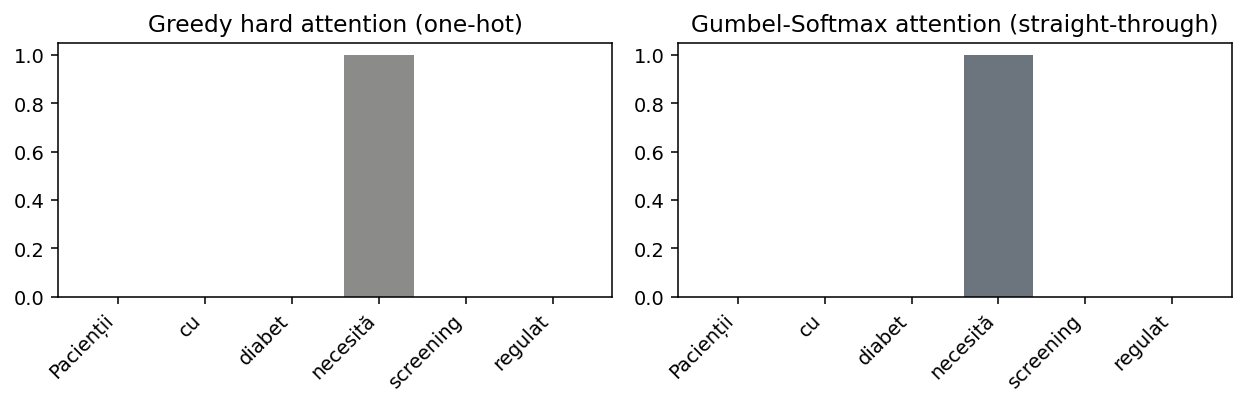

In [ ]:

q = emb(["<query>"]).unsqueeze(0)
ctx_greedy, W_greedy = greedy_hard_attention(q, X, X)
ctx_gumbel, W_gumbel = gumbel_softmax_attention(q, X, X, tau=0.7, hard=True)
fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].bar(range(len(source_tokens)), W_greedy[0,0].detach().numpy(), color="#8B8C89")
ax[0].set_title("Greedy hard attention (one-hot)")
ax[0].set_xticks(range(len(source_tokens)))
ax[0].set_xticklabels(source_tokens, rotation=45, ha='right')
ax[1].bar(range(len(source_tokens)), W_gumbel[0,0].detach().numpy(), color="#6C757D")
ax[1].set_title("Gumbel-Softmax attention (straight-through)")
ax[1].set_xticks(range(len(source_tokens)))
ax[1].set_xticklabels(source_tokens, rotation=45, ha='right')
plt.tight_layout(); plt.show()



## 6) Multi-head self attention — per-head vs. mean
Show diversity of heads and their mean consensus.


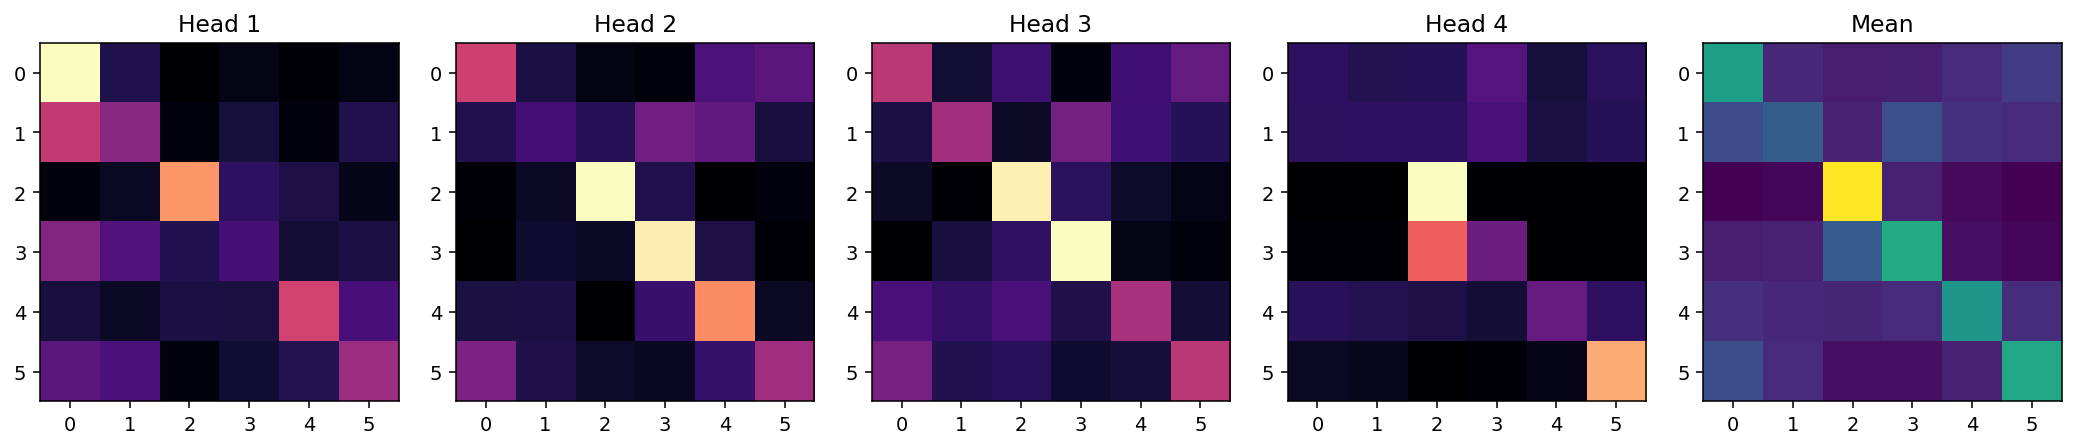

In [ ]:

Ws, W_mean = multihead_self_attention_demo(X, heads=4)
fig, axes = plt.subplots(1, len(Ws)+1, figsize=(3*(len(Ws)+1), 3))
for i, Wh in enumerate(Ws):
    axes[i].imshow(Wh[0].detach().numpy(), cmap='magma')
    axes[i].set_title(f'Head {i+1}')
axes[-1].imshow(W_mean[0].detach().numpy(), cmap='viridis')
axes[-1].set_title('Mean')
plt.tight_layout(); plt.show()



## 7) Sparse masks — quick tour
Window, Longformer (window+global), block-sparse.


window: density=0.667


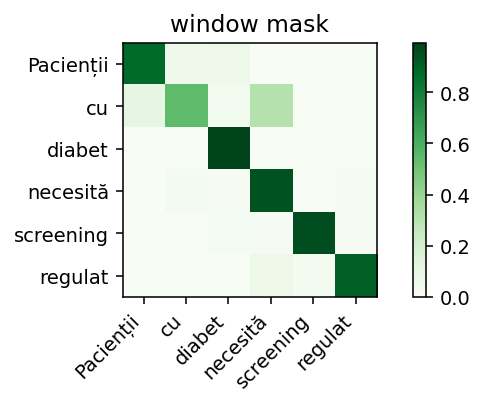

longformer: density=0.833


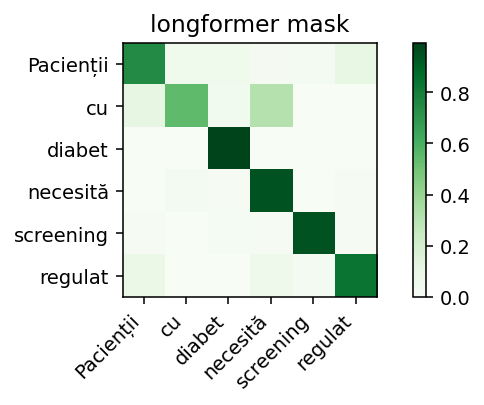

block: density=1.000


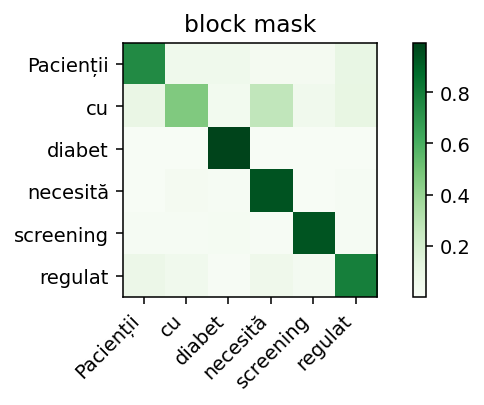

In [ ]:

M_win = sliding_window_mask(X.size(1), w=2, device=X.device)
M_long = longformer_mask(X.size(1), w=2, global_idx=[0], device=X.device)
M_blk = block_sparse_mask(X.size(1), block_size=3, band=1, device=X.device)

for name, M in {'window': M_win, 'longformer': M_long, 'block': M_blk}.items():
    d = mask_density(M)[0]
    print(f'{name}: density={d:.3f}')
    ctx, W = self_attention_unified(X, mask=M)
    AttentionVisualizer(source_tokens).show_matrix(W[0].detach().numpy(), title=f'{name} mask')



---
**Notes**
- All embeddings are random; focus on **shapes** and **patterns**, not semantics.
- The same unified API drives soft, self, cross, local, hard, and sparse variants.
- Save figures with `plt.savefig('figures/<name>.png', dpi=220, bbox_inches='tight')` when you need slide assets.


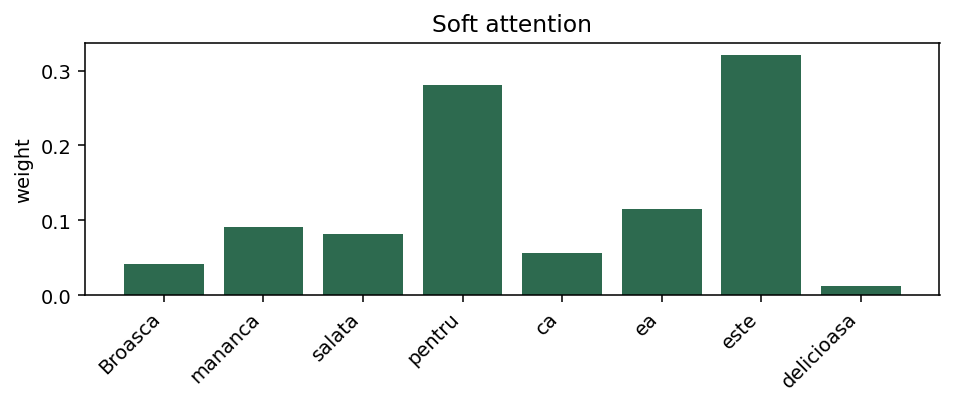

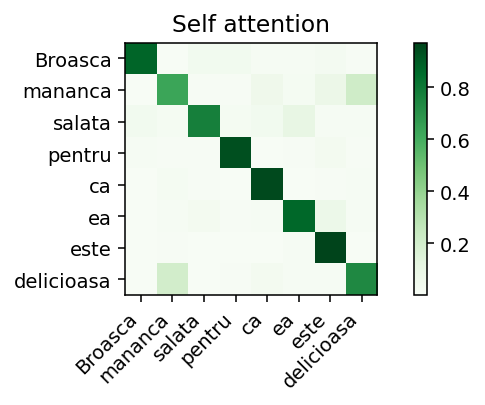

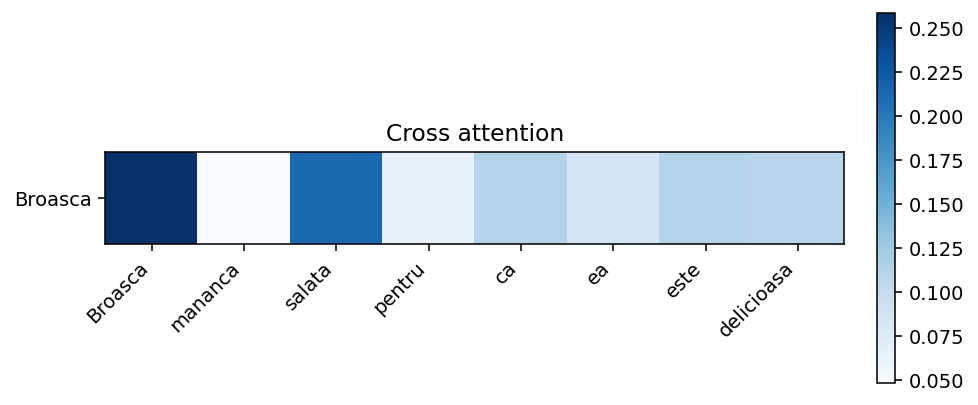

(tensor([[[ 0.2838, -0.1424,  0.3417,  0.2007, -0.0702,  0.4886, -0.0822,
            0.9495,  0.0916,  0.3243,  0.0788,  0.1969,  0.2193, -0.2196,
            0.0329,  0.1491]]]),
 tensor([[[0.2584, 0.0481, 0.2128, 0.0637, 0.1119, 0.0844, 0.1115, 0.1092]]]),
 ['Broasca', 'mananca', 'salata', 'pentru', 'ca', 'ea', 'este', 'delicioasa'])

In [ ]:
run_demo("Broasca mananca salata pentru ca ea este delicioasa", "soft")
run_demo("Broasca mananca salata pentru ca ea este delicioasa", "self")
run_demo("Broasca mananca salata pentru ca ea este delicioasa", "cross")